In [16]:
import pandas as pd

raw_data = pd.read_csv("D:\survey_2025\survey_results_public.csv")
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


C:\Users\USER\AppData\Local\Temp\ipykernel_8704\2193778141.py:3: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv("D:\survey_2025\survey_results_public.csv")


In [18]:
revised_data = raw_data[["Age", "Country", "LanguageHaveWorkedWith","LearnCode"]]
revised_data.head()

,Age,Country,LanguageHaveWorkedWith,LearnCode
0,25-34 years old,Ukraine,Bash/Shell (all shells);Dart;SQL,Online Courses or Certification (includes all ...
1,25-34 years old,Netherlands,Java,Online Courses or Certification (includes all ...
2,35-44 years old,Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,Online Courses or Certification (includes all ...
3,35-44 years old,Ukraine,Java;Kotlin;SQL,"Other online resources (e.g. standard search, ..."
4,35-44 years old,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,NaN


In [19]:
revised_data["Age"]

0        25-34 years old
1        25-34 years old
2        35-44 years old
3        35-44 years old
4        35-44 years old
              ...       
49186    18-24 years old
49187    45-54 years old
49188    35-44 years old
49189    25-34 years old
49190    18-24 years old
Name: Age, Length: 49191, dtype: object

In [25]:
revised_data["Age"].drop_duplicates()

0        25-34 years old
2        35-44 years old
5        45-54 years old
11       18-24 years old
16     65 years or older
20       55-64 years old
370    Prefer not to say
Name: Age, dtype: object

In [26]:
revised_data.groupby(["Age"])

In [27]:
size_by_age = revised_data.groupby(['Age']).size()
size_by_age

Age
18-24 years old       9210
25-34 years old      16519
35-44 years old      13241
45-54 years old       6275
55-64 years old       2626
65 years or older      942
Prefer not to say      378
dtype: int64

<Axes: ylabel='Age'>

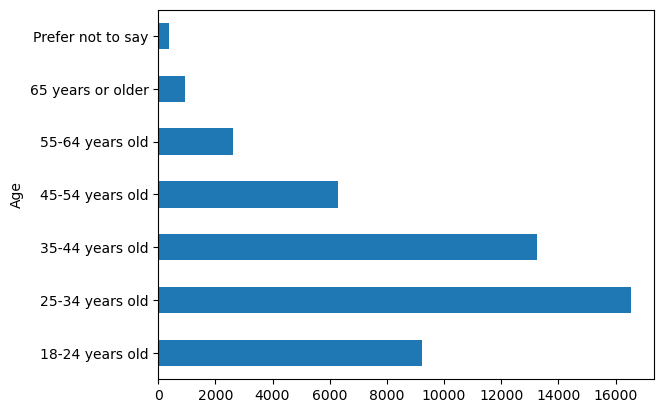

In [28]:
# 수평 막대그래프 그리기
size_by_age.plot.barh()  # horizontal 

In [29]:
# 현재 색인 확인하기
size_by_age.index

Index(['18-24 years old', '25-34 years old', '35-44 years old',
       '45-54 years old', '55-64 years old', '65 years or older',
       'Prefer not to say'],
      dtype='object', name='Age')

In [30]:
# 재색인하기
reindxed_size_by_age = size_by_age.reindex(index=[
    'Prefer not to say',
    '65 years or older',
    '55-64 years old',
    '45-54 years old',
    '35-44 years old',
    '25-34 years old',
    '18-24 years old',
    'Under 18 years old' 
])


# 재색인한 결과 확인하기
reindxed_size_by_age
    

Age
Prefer not to say       378.0
65 years or older       942.0
55-64 years old        2626.0
45-54 years old        6275.0
35-44 years old       13241.0
25-34 years old       16519.0
18-24 years old        9210.0
Under 18 years old        NaN
dtype: float64

<Axes: ylabel='Age'>

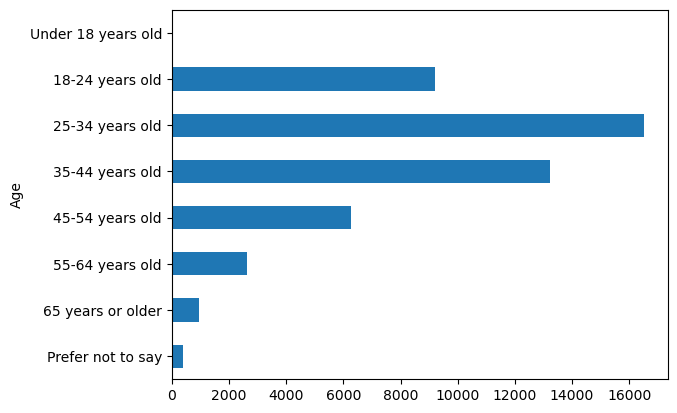

In [31]:
reindxed_size_by_age.plot.barh()

In [32]:
size_by_country = revised_data.groupby(["Country"]).size()

<Axes: >

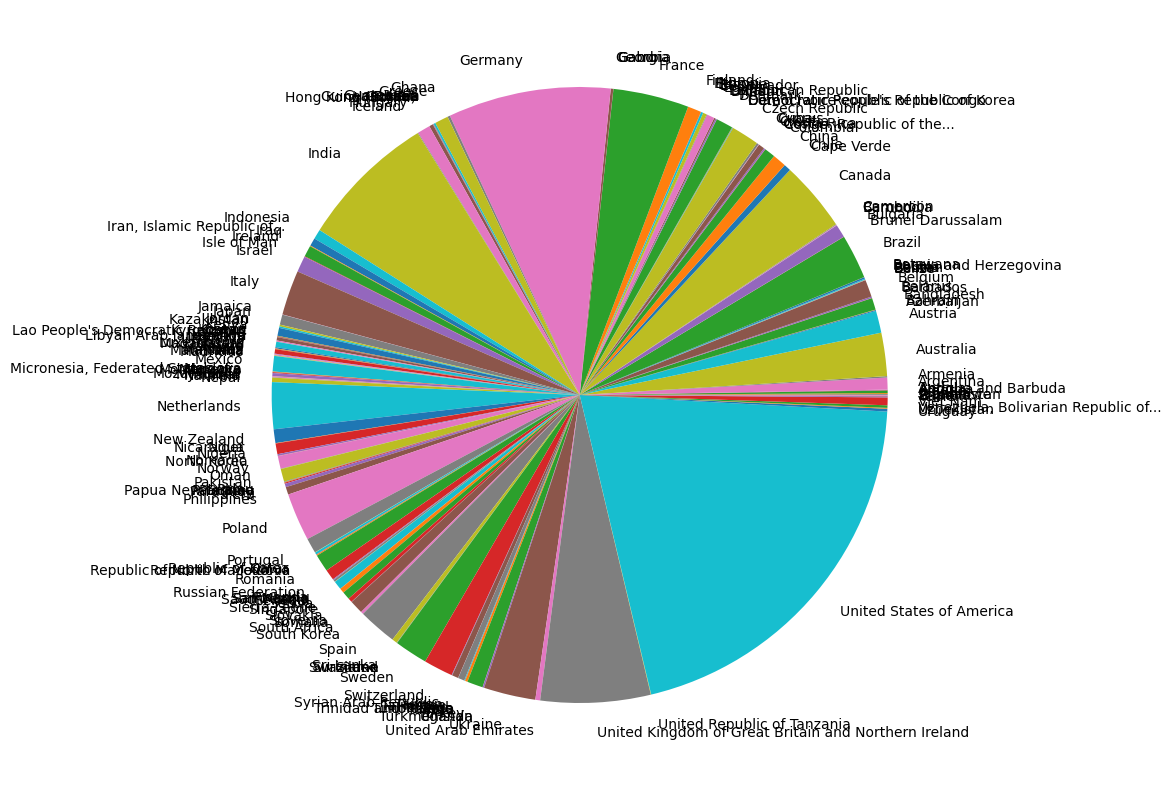

In [33]:
# 기본 파이 그래프 그리기
size_by_country.plot.pie(figsize=(10,10))

In [34]:
# 국가 상위 20개 확인하기
size_by_country.nlargest(20)

Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409
Canada                                                  1305
Ukraine                                                  964
Poland                                                   888
Netherlands                                              867
Italy                                                    835
Brazil                                                   825
Australia                                                804
Spain                                                    717
Sweden                                                   616
Switzerland                                              546
Czech Republic                                           520
Austria         

<Axes: >

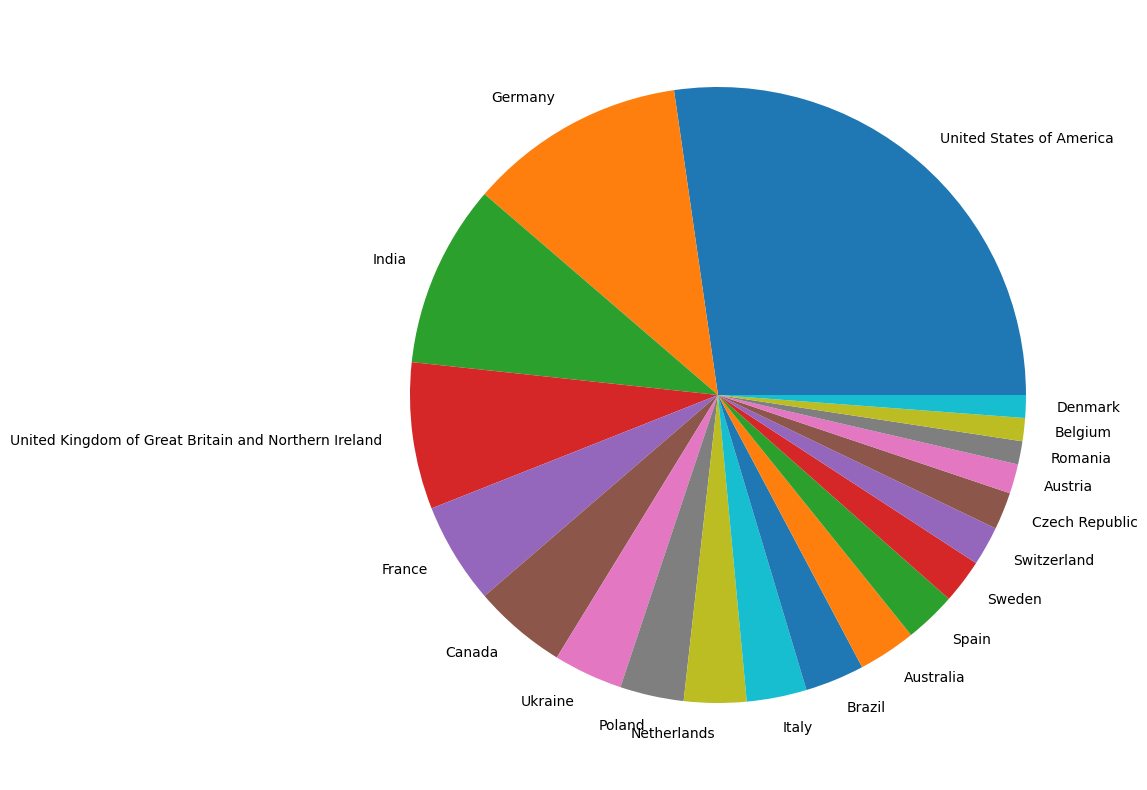

In [35]:
# 국가 상위 20개 파이 그래프 그리기
size_by_country.nlargest(20).plot.pie(figsize=(10,10))

In [36]:
# 프로그래밍 언어 데이터 추출
languages = revised_data["LanguageHaveWorkedWith"]

# 데이터 확인
languages

0                         Bash/Shell (all shells);Dart;SQL
1                                                     Java
2                      Dart;HTML/CSS;JavaScript;TypeScript
3                                          Java;Kotlin;SQL
4        C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...
                               ...                        
49186                                                  NaN
49187                                                  NaN
49188                                                  NaN
49189                                                  NaN
49190                                                  NaN
Name: LanguageHaveWorkedWith, Length: 49191, dtype: object

In [37]:
# 데이터 문자열 변환 후 구분자(;)로 구분
languages = languages.str.split(";")

# 데이터 확인
languages

0                     [Bash/Shell (all shells), Dart, SQL]
1                                                   [Java]
2                 [Dart, HTML/CSS, JavaScript, TypeScript]
3                                      [Java, Kotlin, SQL]
4        [C, C#, C++, Delphi, HTML/CSS, Java, JavaScrip...
                               ...                        
49186                                                  NaN
49187                                                  NaN
49188                                                  NaN
49189                                                  NaN
49190                                                  NaN
Name: LanguageHaveWorkedWith, Length: 49191, dtype: object

In [38]:
# 리스트 항목을 행으로 나누기
exploded_languages = languages.explode()

# 데이터 확인
exploded_languages

0        Bash/Shell (all shells)
0                           Dart
0                            SQL
1                           Java
2                           Dart
                  ...           
49186                        NaN
49187                        NaN
49188                        NaN
49189                        NaN
49190                        NaN
Name: LanguageHaveWorkedWith, Length: 212104, dtype: object

In [39]:
# 프로그래밍별 응담 수 구하기
size_by_languages = exploded_languages.groupby(exploded_languages).size()

# 데이터 확인
size_by_languages

LanguageHaveWorkedWith
Ada                          431
Assembly                    2246
Bash/Shell (all shells)    15503
C                           6987
C#                          8852
C++                         7485
COBOL                        308
Dart                        1885
Delphi                       796
Elixir                       847
Erlang                       465
F#                           406
Fortran                      449
GDScript                    1062
Gleam                        354
Go                          5219
Groovy                      1535
HTML/CSS                   19698
Java                        9358
JavaScript                 21005
Kotlin                      3420
Lisp                         753
Lua                         2910
MATLAB                      1231
MicroPython                  723
Mojo                         145
OCaml                        367
PHP                         5994
Perl                        1215
PowerShell          

<Axes: ylabel='LanguageHaveWorkedWith'>

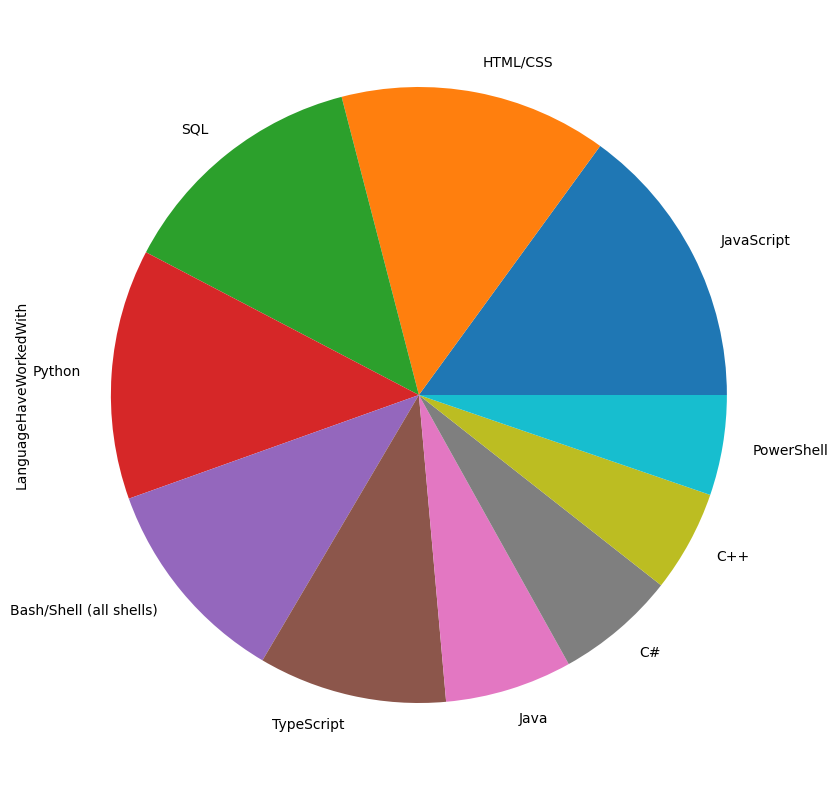

In [40]:
# 상위 10개만 집계하여 파이 그래프 그리기
size_by_languages.nlargest(10).plot.pie(figsize=(10,10))

<Axes: ylabel='LanguageHaveWorkedWith'>

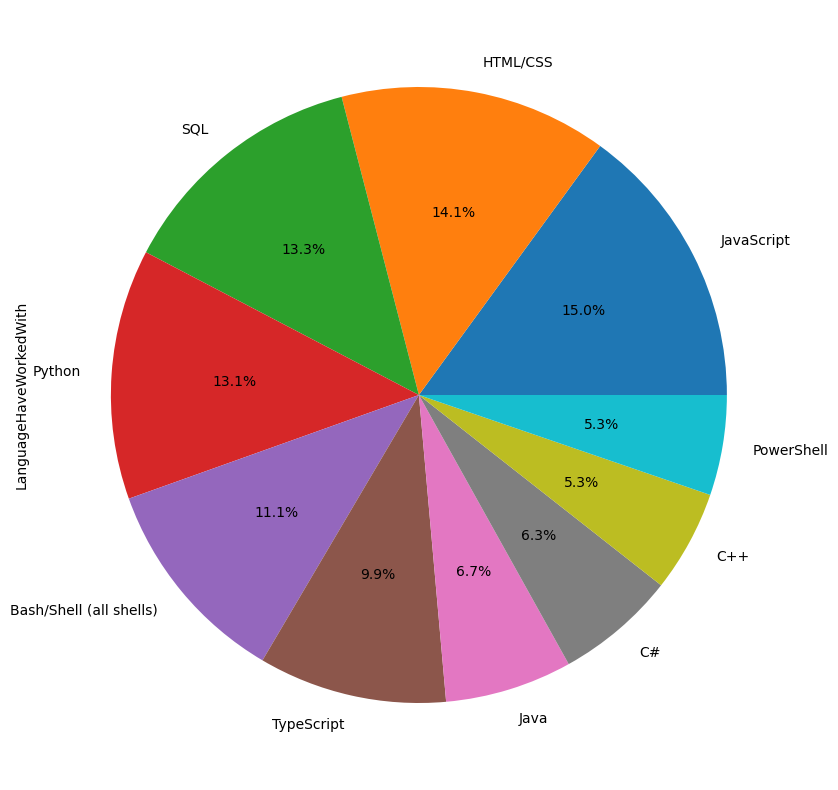

In [42]:
# 백분율 표기하기
size_by_languages.nlargest(10).plot.pie(figsize=(10,10), autopct='%1.01f%%')

In [43]:
# 25~34세 연령대가 사용한 프로그래밍 언어 정보 추출
languages_for_25_34 = revised_data[revised_data.Age == '25-34 years old']["LanguageHaveWorkedWith"].str.split(";").explode()


# 데이터 확인
languages_for_25_34

0        Bash/Shell (all shells)
0                           Dart
0                            SQL
1                           Java
6                     JavaScript
                  ...           
49179                      Swift
49181                        NaN
49183                        NaN
49185                        NaN
49189                        NaN
Name: LanguageHaveWorkedWith, Length: 68342, dtype: object

<Axes: ylabel='LanguageHaveWorkedWith'>

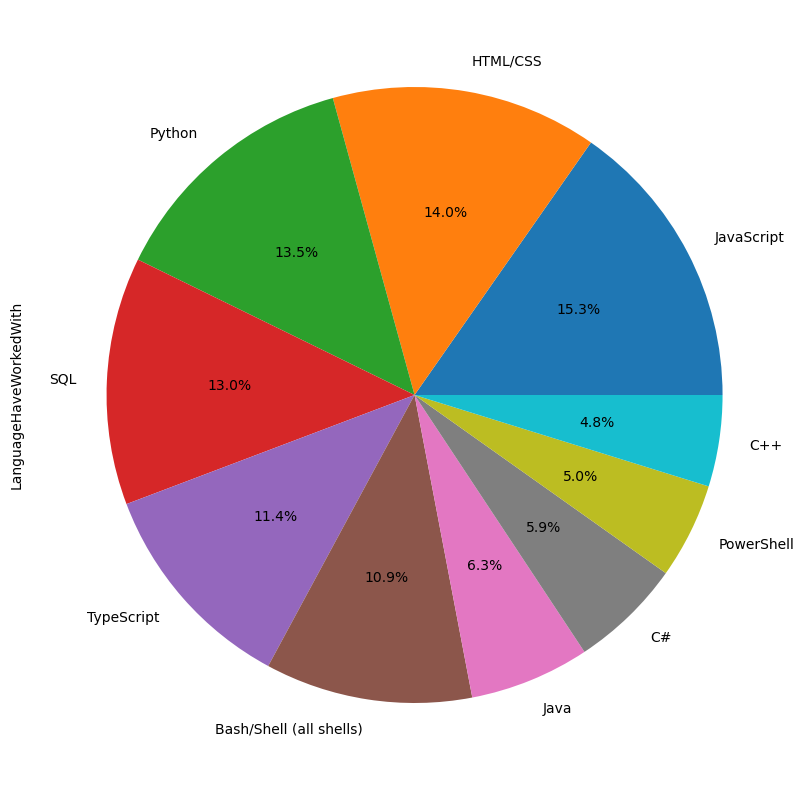

In [44]:
# 상위 10개 데이터 파이 그래프 그리기
languages_for_25_34.groupby(languages_for_25_34).size().nlargest(10).plot.pie(figsize=(10,10), autopct='%1.01f%%')